# Comp 352 Final Project - Moneyball

**Authors:** Tyler Hayes, Zach Hersick and Will Sydorak

**Date:** 5/19/2026

### Moneyball: MLB Stats

#### Full dataset: https://www.kaggle.com/datasets/wduckett/moneyball-mlb-stats-19622012

A data-driven analysis of MLB team performance (1962–2012), using Moneyball-style metrics to build predictive models for seasonal win totals.

### Final Project Requirements:  

- **Data Importing and Pre-processing (100 Points)**
    - Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
    - Clean, wrangle, and handle missing data, duplicate data, etc.
    - Encode any categorical variables
    - Perform feature engineering on the dataset
    - Transform data appropriately using techniques such as aggregation, normalization, and feature construction
    - Reduce redundant data and perform need based discretization
- **Data Analysis and Visualization (100 Points)**
    - Identify categorical, ordinal, and numerical variables within data
    - Provide measures of centrality and distribution with visualizations
    - Diagnose for correlations between variables and determine independent and dependent variables
    - Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest
    - Create visualizations that allow for the discovery of insights in the data
- **Data Analytics (100 Points)**
    - Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
    - Choose and provide reasoning for the selected metric or metrics employed to assess your model.
    - Train, test, cross validate, and provide performance metrics for model results
    - Try multiple different types of algorithms to determine the best model for your dataset
    - Analyze your model performance
- **Presentation & Peer Evaluation (50 Points)**
    - In a 5 to 10 minute slide presentation, briefly explain the project workflow from the code and results in your markdown notebook
    - See presentation example  for an outline of what the presentation should look like
    - This presentation will be given in front of the class on the day of the final exam. You must be in attendance to receive credit for this portion of the project, unless the professor excuses your absence.
    - State your findings from the data and provide the interpretation of results from your analysis at each stage in the project
    - Be sure to properly label visualizations in your presentation (axis labels, human readable column names, etc.) 
    - Complete the peer evaluation form  for each member of the group.

## Table of Contents:
* [Environment Setup](#env-setup)
* [Data Importing and Pre-processing](#data-importing)
* [Data Analysis and Visualization](#data-vis)
* [Data Analytics](#data-analytics)

## Environment Setup <a class="anchor" id="env-setup"></a>

All dependencies are listed in `requirements.txt`. To install them, run the following in your terminal before opening the notebook:

```bash
pip install -r requirements.txt
```

If you are using a virtual environment (recommended), set it up first:

```bash
python -m venv venv
source venv/bin/activate        # Mac/Linux
venv\Scripts\activate           # Windows
pip install -r requirements.txt
```

Then open the notebook with `jupyter notebook` or in VS Code with the Jupyter extension.

In [2]:
!pip install pandas
!pip install numpy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Importing and Pre-processing <a class="anchor" id="data-importing"></a>

In [3]:
import numpy as np
import pandas as pd

# Import dataset
df = pd.read_csv('baseball.csv')

#describe characteristics such as dimensions, data types, file types
print(f'Shape: {df.shape}')
print(f'Dtypes: {df.dtypes}')
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())

#drop duplicates (should be none)
df = df.drop_duplicates().copy()

#because teams relocated/changed named, map the names from the same franchise but different team names
franchise_map = {
    "CAL": "LAA", "ANA": "LAA", "LAA": "LAA",
    "FLA": "MIA", "MIA": "MIA",
    "MON": "WSN", "WSN": "WSN",
    "TBD": "TBR", "TBR": "TBR",
    "MLN": "ATL", "ATL": "ATL",
    "WSA": "TEX", "TEX": "TEX",
    "KCA": "OAK", "OAK": "OAK",
    "SEP": "MIL", "MIL": "MIL"
}

df["Franchise"] = df["Team"].replace(franchise_map)
df = df.drop(columns=["Team"])

#drop opponent values because they are absent before 1999, RankSeason and RankPlayoffs because they are only present for playoff teams, and Playoffs because
#it is downstream from wins and causes data leakage
drop_cols = ['OOBP', 'OSLG', 'RankSeason', 'RankPlayoffs', 'Playoffs']
df = df.drop(columns=drop_cols)

#feature engineering
df = df.sort_values(['Franchise', 'Year']).copy()
grouped = df.groupby('Franchise')

df["run_diff"] = df["RS"] - df["RA"]
df["RS_per_game"] = df["RS"] / df["G"]
df["RA_per_game"] = df["RA"] / df["G"]
df["OPS"] = df["OBP"] + df["SLG"]

df["prev_wins"] = grouped["W"].shift(1)
df["wins_3yr_avg"] = grouped["W"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
df["prev_run_diff"] = grouped["run_diff"].shift(1)
df["OBP_3yr_avg"] = grouped["OBP"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
df["SLG_3yr_avg"] = grouped["SLG"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

#fill missing values caused by rolling/lagging
df["prev_wins"] = df["prev_wins"].fillna(df["wins_3yr_avg"])
df["wins_3yr_avg"] = df["wins_3yr_avg"].fillna(df["wins_3yr_avg"].median())
df["prev_run_diff"] = df["prev_run_diff"].fillna(0)
df["OBP_3yr_avg"] = df["OBP_3yr_avg"].fillna(df["OBP_3yr_avg"].median())
df["SLG_3yr_avg"] = df["SLG_3yr_avg"].fillna(df["SLG_3yr_avg"].median())

#discretization
df["era"] = pd.cut(
    df["Year"],
    bins=[1961, 1976, 1993, 1998, 2012],
    labels=["1962_1976", "1977_1993", "1994_1998", "1999_2012"]
)

#encode
df = pd.get_dummies(df, columns=['League', 'Franchise', 'era'], drop_first=True)

#csv for easier viewing
df = df.sort_values(['Year'], ascending=False).reset_index(drop=True)
df.to_csv("baseball_cleaned.csv", index=False)

#we will normalize after split


Shape: (1232, 15)
Dtypes: Team             object
League           object
Year              int64
RS                int64
RA                int64
W                 int64
OBP             float64
SLG             float64
BA              float64
Playoffs          int64
RankSeason      float64
RankPlayoffs    float64
G                 int64
OOBP            float64
OSLG            float64
dtype: object

Columns:
 ['Team', 'League', 'Year', 'RS', 'RA', 'W', 'OBP', 'SLG', 'BA', 'Playoffs', 'RankSeason', 'RankPlayoffs', 'G', 'OOBP', 'OSLG']

Missing values:
 Team              0
League            0
Year              0
RS                0
RA                0
W                 0
OBP               0
SLG               0
BA                0
Playoffs          0
RankSeason      988
RankPlayoffs    988
G                 0
OOBP            812
OSLG            812
dtype: int64

Duplicates: 0


## Data Analysis and Visualization <a class="anchor" id="data-vis"></a>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

# Load data
df = pd.read_csv('baseball_cleaned.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1232, 50)


,Year,RS,RA,W,OBP,SLG,BA,G,run_diff,RS_per_game,...,Franchise_SEA,Franchise_SFG,Franchise_STL,Franchise_TBR,Franchise_TEX,Franchise_TOR,Franchise_WSN,era_1977_1993,era_1994_1998,era_1999_2012
0,2012,667,845,68,0.324,0.381,0.251,162,-178,4.117284,...,False,False,False,False,False,False,False,False,False,True
1,2012,697,577,90,0.317,0.394,0.240,162,120,4.302469,...,False,False,False,True,False,False,False,False,False,True
2,2012,726,670,88,0.335,0.422,0.268,162,56,4.481481,...,False,False,False,False,False,False,False,False,False,True
3,2012,758,890,64,0.330,0.436,0.274,162,-132,4.679012,...,False,False,False,False,False,False,False,False,False,True
4,2012,583,794,55,0.302,0.371,0.236,162,-211,3.598765,...,False,False,False,False,False,False,False,False,False,True


### 1. Variable Identification

We classify all 50 columns into three types:
- Numerical: Continuous/ratio variables representing counts, rates, and averages
- Ordinal: Variables with a meaningful order (Year)
- Categorical: Nominal variables encoded as binary dummy columns (Franchise, League, Era)

In [5]:
# --- Variable Classification ---

numerical_vars = [
    'RS', 'RA', 'W', 'OBP', 'SLG', 'BA', 'OPS',
    'RS_per_game', 'RA_per_game', 'run_diff',
    'prev_wins', 'wins_3yr_avg', 'prev_run_diff',
    'OBP_3yr_avg', 'SLG_3yr_avg'
]

ordinal_vars = ['Year']  # Treated ordinally to capture time trends

categorical_vars = (
    ['League_NL'] +
    [c for c in df.columns if c.startswith('Franchise_')] +
    [c for c in df.columns if c.startswith('era_')]
)

print("=" * 50)
print(f"NUMERICAL  ({len(numerical_vars)} vars): {numerical_vars}")
print(f"ORDINAL    ({len(ordinal_vars)} var):  {ordinal_vars}")
print(f"CATEGORICAL ({len(categorical_vars)} vars):")
print("Note: Franchise, League, and Era are one-hot encoded.")

NUMERICAL  (15 vars): ['RS', 'RA', 'W', 'OBP', 'SLG', 'BA', 'OPS', 'RS_per_game', 'RA_per_game', 'run_diff', 'prev_wins', 'wins_3yr_avg', 'prev_run_diff', 'OBP_3yr_avg', 'SLG_3yr_avg']
ORDINAL    (1 var):  ['Year']
CATEGORICAL (33 vars):
Note: Franchise, League, and Era are one-hot encoded.


### 2. Measures of Centrality and Distribution

For each numerical variable we report mean, median, standard deviation, range, and skewness, then visualize distributions with histograms and box plots.

The dependent variable is W (wins). All others are treated as potential independent variables.

In [6]:
# --- Summary Statistics ---

stats = df[numerical_vars].describe().T.rename(columns={'50%': 'median'})
stats['skewness'] = df[numerical_vars].skew()
stats['range'] = stats['max'] - stats['min']

display(stats[['mean', 'median', 'std', 'min', 'max', 'range', 'skewness']].round(3))

,mean,median,std,min,max,range,skewness
RS,715.082,711.000,91.534,463.000,1009.000,546.000,0.175
RA,715.082,709.000,93.080,472.000,1103.000,631.000,0.299
W,80.904,81.000,11.458,40.000,116.000,76.000,-0.182
OBP,0.326,0.326,0.015,0.277,0.373,0.096,0.018
SLG,0.397,0.396,0.033,0.301,0.491,0.190,0.054
BA,0.259,0.260,0.013,0.214,0.294,0.080,-0.111
OPS,0.724,0.722,0.046,0.584,0.851,0.267,0.031
RS_per_game,4.416,4.395,0.564,2.858,6.228,3.370,0.171
RA_per_game,4.416,4.383,0.575,2.914,6.809,3.895,0.296
run_diff,0.000,4.000,102.785,-337.000,309.000,646.000,-0.189


**Histograms: distribution shape for key variables**

Histograms reveal whether distributions are normal, skewed, or multimodal. A KDE curve is overlaid for smoother shape visualization.

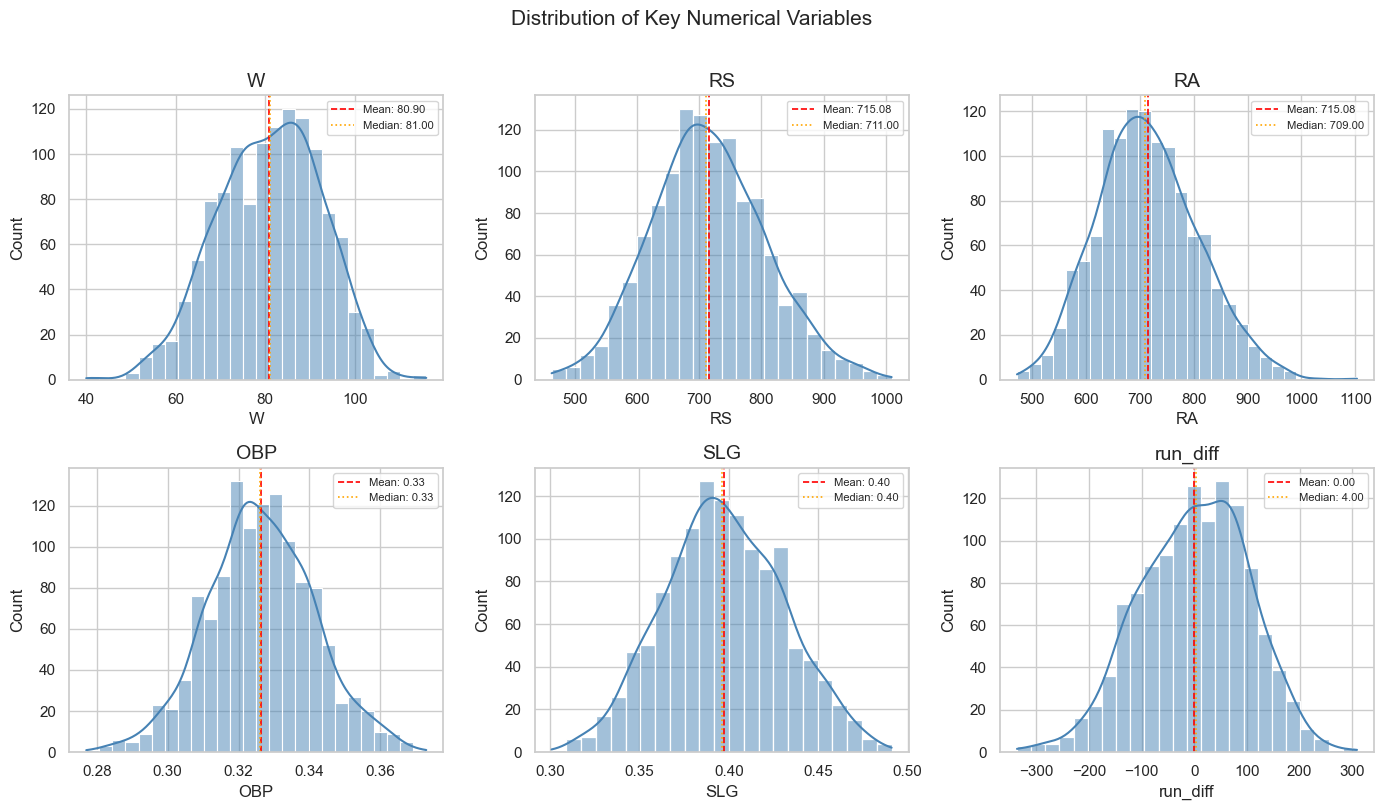

In [7]:
# --- Histograms for key variables ---

key_vars = ['W', 'RS', 'RA', 'OBP', 'SLG', 'run_diff']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.histplot(df[var], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].axvline(df[var].mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {df[var].mean():.2f}')
    axes[i].axvline(df[var].median(), color='orange', linestyle=':',  linewidth=1.2, label=f'Median: {df[var].median():.2f}')
    axes[i].set_title(var)
    axes[i].legend(fontsize=8)

fig.suptitle('Distribution of Key Numerical Variables', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Histogram Observations:
- W (Wins): Roughly normal, centered around 81 wins right at the 162-game season midpoint. Slight right skew, meaning a few dominant teams pull the mean up marginally.
- RS (Runs Scored): Also near-normal, centered around 715. The long right tail shows a handful of historically elite offenses scoring 900+ runs in a season.
- RA (Runs Allowed): Nearly identical distribution to RS, same center and spread, which makes sense since every run scored by one team is allowed by another across the league.
- OBP: Tight, symmetric distribution centered at 0.33. Very little spread, meaning most teams cluster close to the league average. Outliers are rare.
- SLG: Similar shape to OBP, centered at 0.40. Slightly more spread than OBP, suggesting slugging varies a bit more team-to-team than on-base percentage.
- run_diff: Centered near zero as expected across a full season, total runs scored and allowed league-wide balance out. The spread (roughly -300 to +300) captures the gap between the worst and best teams in a given year.

**Box plots: spread and outliers by league**

Box plots compare spread and central tendency across AL and NL, and highlight outliers.

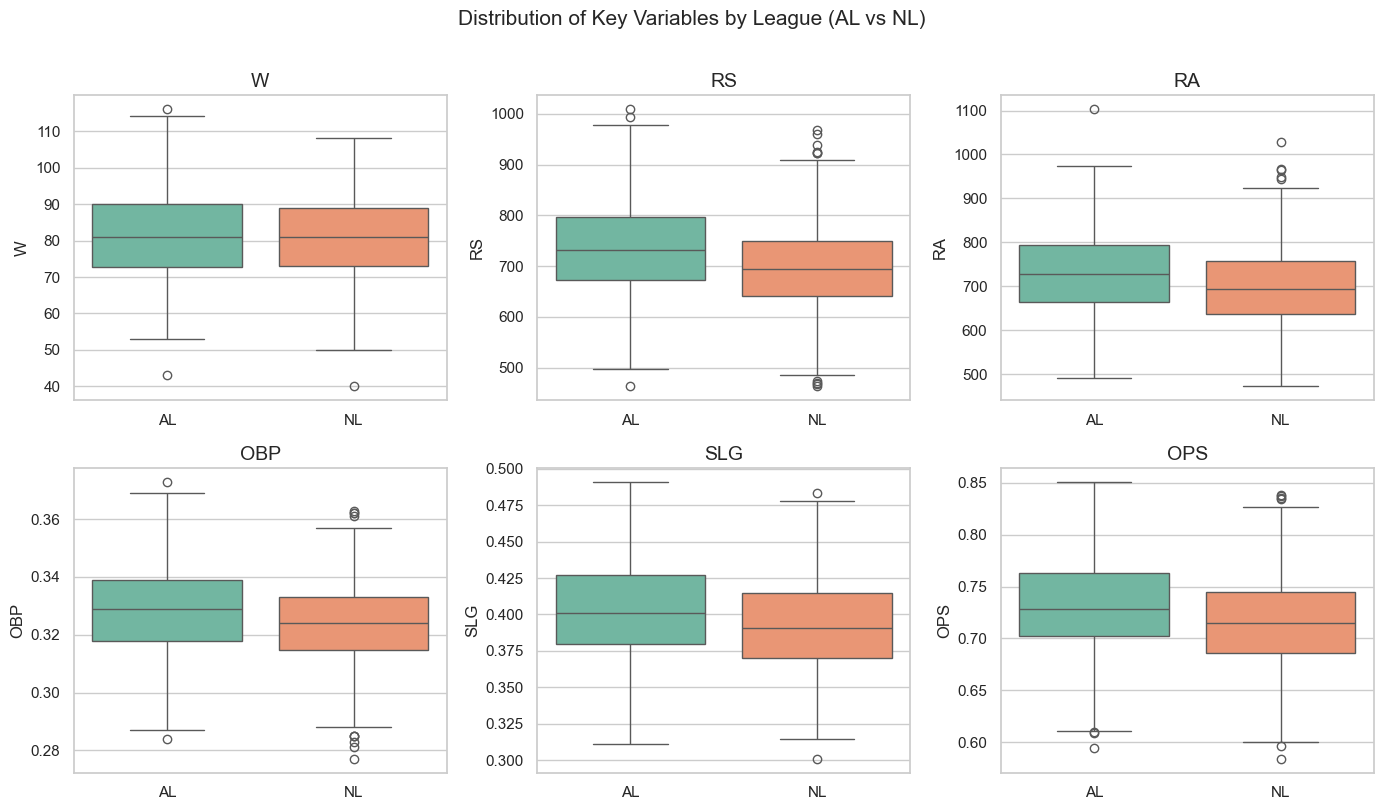

In [8]:
# --- Box plots by League ---

df['League'] = df['League_NL'].map({True: 'NL', False: 'AL'})

box_vars = ['W', 'RS', 'RA', 'OBP', 'SLG', 'OPS']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(box_vars):
    sns.boxplot(data=df, x='League', y=var, ax=axes[i], hue='League', legend=False, palette='Set2')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

fig.suptitle('Distribution of Key Variables by League (AL vs NL)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Box Plot Observations:
- W (Wins): Nearly identical distributions between AL and NL, same median (~81), same spread. League affiliation alone doesn't explain win totals.
- RS (Runs Scored): AL teams score noticeably more runs than NL teams. This is likely attributable to the designated hitter (DH) rule, AL teams don't have pitchers hitting, so their lineups are stronger top to bottom.
- RA (Runs Allowed): AL teams also allow more runs, which aligns with the RS finding, since AL offenses are stronger, they inflate run totals on both sides of the ball.
- OBP: AL teams have a slightly higher median OBP, consistent with the DH effect. The difference is small but visible.
- SLG: Similar story, AL teams slug marginally better, again likely DH-driven. NL has more outliers on the low end.
- OPS: Combines OBP and SLG, so unsurprisingly AL teams show a slightly higher median OPS. The gap is modest, suggesting the DH advantage exists but isn't enormous.

### 3. Correlation Diagnosis and Variable Roles
**Dependent vs. Independent Variables**

- Dependent variable (target): W (wins) - what we are trying to predict
- Independent variables (features): all remaining numerical columns

Before modeling, we diagnose correlations to understand which features are most predictive of wins, and to identify multicollinearity between independent variables.

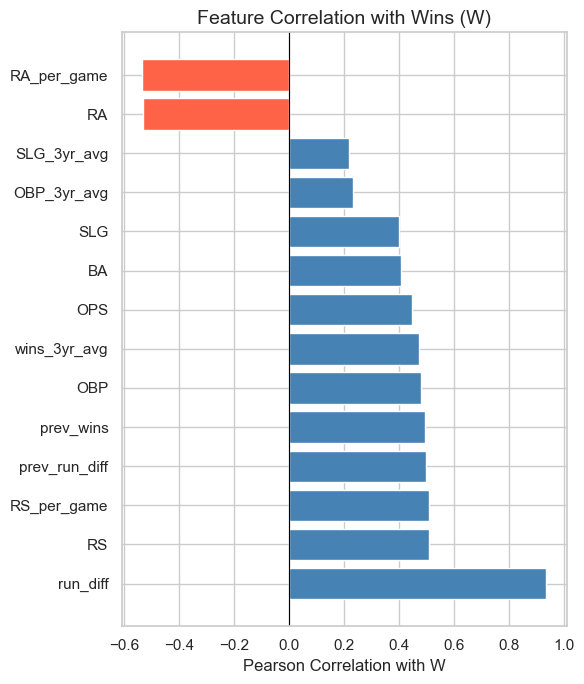

                   W
run_diff       0.938
RS             0.512
RS_per_game    0.510
prev_run_diff  0.500
prev_wins      0.497
OBP            0.482
wins_3yr_avg   0.473
OPS            0.447
BA             0.409
SLG            0.401
OBP_3yr_avg    0.234
SLG_3yr_avg    0.217
RA            -0.532
RA_per_game   -0.535


In [9]:
# --- Correlation with target variable W ---

corr_with_W = df[numerical_vars].corr()[['W']].drop('W').sort_values('W', ascending=False)

fig, ax = plt.subplots(figsize=(6, 7))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_with_W['W']]
ax.barh(corr_with_W.index, corr_with_W['W'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with W')
ax.set_title('Feature Correlation with Wins (W)')
plt.tight_layout()
plt.show()

print(corr_with_W.round(3))

Feature Correlation Observations:
- run_diff is by far the strongest predictor of wins (r ≈ 0.94), nearly a perfect linear relationship. This is the core Moneyball insight that run differential almost fully determines a team's win total.
- RS and RS_per_game (r ≈ 0.51) are the next strongest positive predictors, confirming that scoring runs is a primary driver of winning. OBP (r ≈ 0.48) and OPS (r ≈ 0.45) follow closely, validating the Moneyball emphasis on on-base percentage as a key offensive metric over traditional stats like BA (r ≈ 0.41), which correlates slightly less.
- prev_wins, prev_run_diff, and wins_3yr_avg all sit in the 0.47-0.50 range, showing that past performance is a meaningful but not dominant predictor. Reams that were good last year tend to stay good, but current-season stats are more informative.
- SLG_3yr_avg and OBP_3yr_avg are the weakest positive predictors (r ≈ 0.22), suggesting that multi-year hitting averages smooth out too much variation to be strongly predictive on their own.
- RA and RA_per_game are the only negative correlators (r ≈ -0.53), which makes intuitive sense, allowing more runs directly reduces wins. Their magnitude is slightly stronger than RS, hinting that pitching and defense may matter marginally more than offense in determining wins.

**Correlation heatmap: full numerical variable matrix**

The heatmap reveals both correlations with the target and multicollinearity between independent variables. Highly correlated feature pairs (e.g. RS and RS_per_game) are essentially redundant and will be addressed in modeling.

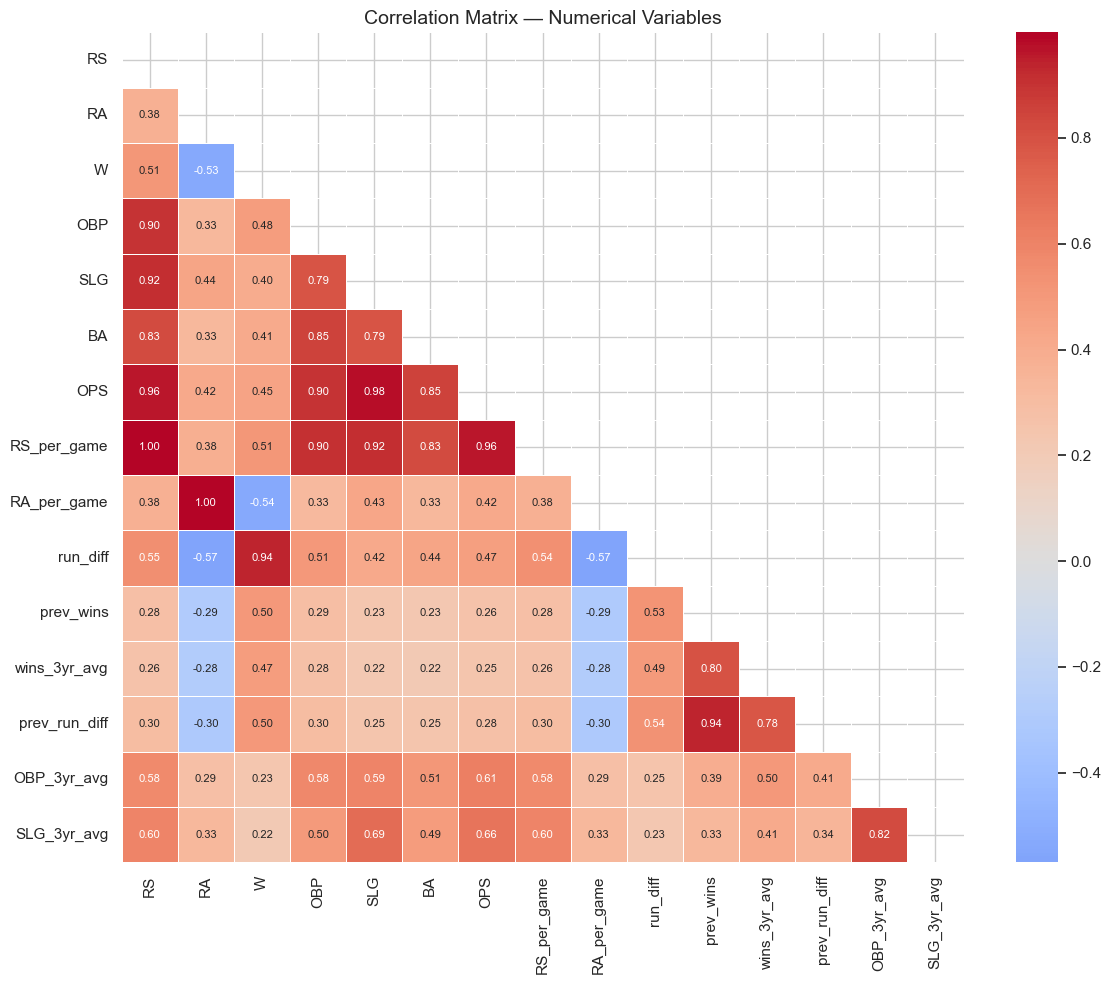

In [10]:
# --- Full correlation heatmap ---

corr_matrix = df[numerical_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Correlation Matrix — Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

Key findings: 
- Strongest positive predictors of W: run_diff (r=0.94), RS (r=0.51), OBP (r=0.48)
- Strongest negative predictors of W: RA_per_game (r=-0.54), RA (r=-0.53)
- Multicollinearity flags: RS and RS_per_game are nearly identical, as are RA and RA_per_game. run_diff is computed from RS - RA, making it linearly dependent on both.
- Lagged features (prev_wins, wins_3yr_avg, prev_run_diff) show moderate correlation (~0.47-0.50), suggesting past performance has predictive value.

**4. Exploratory Analysis and Visualization**

This section combines exploratory analysis with insight-driven visualizations. Each plot surfaces a specific pattern: from how offense has shifted across eras, to the near-linear relationship between run differential and wins.

**Average runs scored and allowed over time**

RS and RA trends across seasons with era boundary markers.

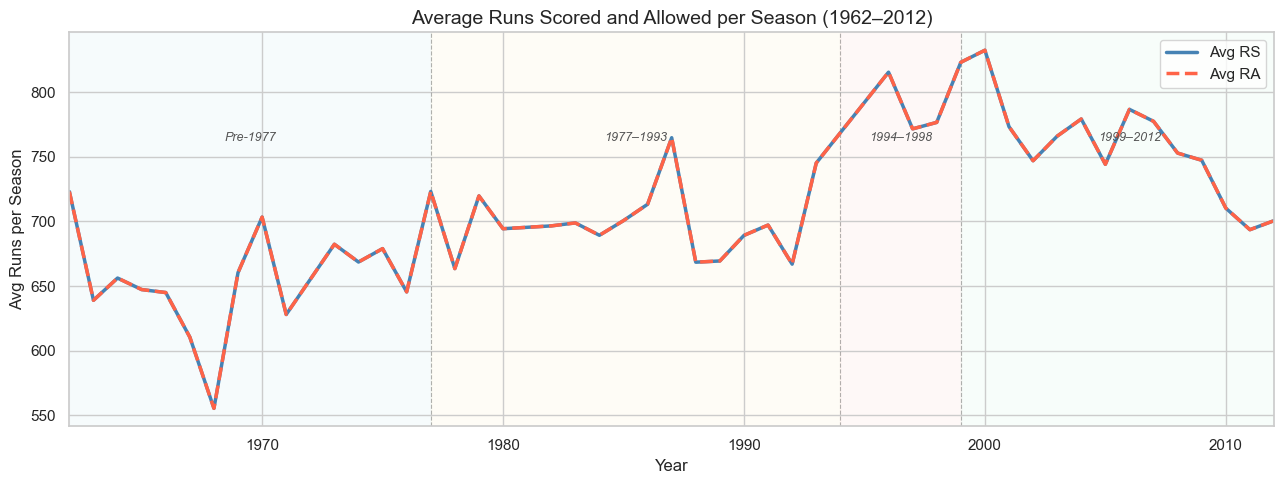

In [11]:
# --- RS and RA trends over time ---

def get_era(row):
    if row['era_1977_1993']: return '1977–1993'
    elif row['era_1994_1998']: return '1994–1998'
    elif row['era_1999_2012']: return '1999–2012'
    else: return 'Pre-1977'

df['Era'] = df.apply(get_era, axis=1)
era_order = ['Pre-1977', '1977–1993', '1994–1998', '1999–2012']
yearly = df.groupby('Year')[['RS', 'RA', 'W']].mean().reset_index()

# Era boundaries: start year, end year, label, shade color
eras = [
    (1962, 1977, 'Pre-1977',  '#e8f4f8'),
    (1977, 1994, '1977–1993', '#fef9e7'),
    (1994, 1999, '1994–1998', '#fdecea'),
    (1999, 2013, '1999–2012', '#eafaf1'),
]

fig, ax = plt.subplots(figsize=(13, 5))

# Shade era bands first (drawn behind the lines)
for start, end, lbl, color in eras:
    ax.axvspan(start, end, alpha=0.35, color=color, zorder=0)
    ax.text((start + end) / 2, 760, lbl,
            ha='center', va='bottom', fontsize=9,
            color='#555', fontstyle='italic')

# Era boundary lines
for yr in [1977, 1994, 1999]:
    ax.axvline(yr, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

# Plot lines on top
ax.plot(yearly['Year'], yearly['RS'], label='Avg RS', color='steelblue', linewidth=2.5, zorder=2)
ax.plot(yearly['Year'], yearly['RA'], label='Avg RA', color='tomato',    linewidth=2.5, linestyle='--', zorder=2)

ax.set_xlabel('Year')
ax.set_ylabel('Avg Runs per Season')
ax.set_title('Average Runs Scored and Allowed per Season (1962–2012)')
ax.set_xlim(1962, 2012)
ax.legend()
plt.tight_layout()
plt.show()

Observations:
- Pre-1977: Run scoring starts high (~725) in the early 1960s, drops sharply through the late 1960s, hitting a low around 1968, known historically as the "Year of the Pitcher", then gradually recovers toward the era boundary.
- 1977-1993: A relatively stable offensive environment with runs hovering in the 680-760 range. The introduction of the DH in 1973 (fully reflected by this era) helped stabilize scoring, though year-to-year variance remains.
- 1994-1998: A sharp and sustained offensive explosion. Average runs jump well above 750 and peak near 820. This aligns with the start of the steroid era and expansion of the league adding weaker pitching talent to the pool.
- 1999-2012: Scoring remains elevated early, peaking around 2000, then steadily declines through the 2000s as stricter PED enforcement and improved pitching depth brought run totals back down toward pre-steroid levels by 2012.
- RS vs. RA: The two lines track almost perfectly throughout all eras confirming that run differential stays near zero league-wide, as expected. Any separation between them in a given year reflects sampling variation across teams.

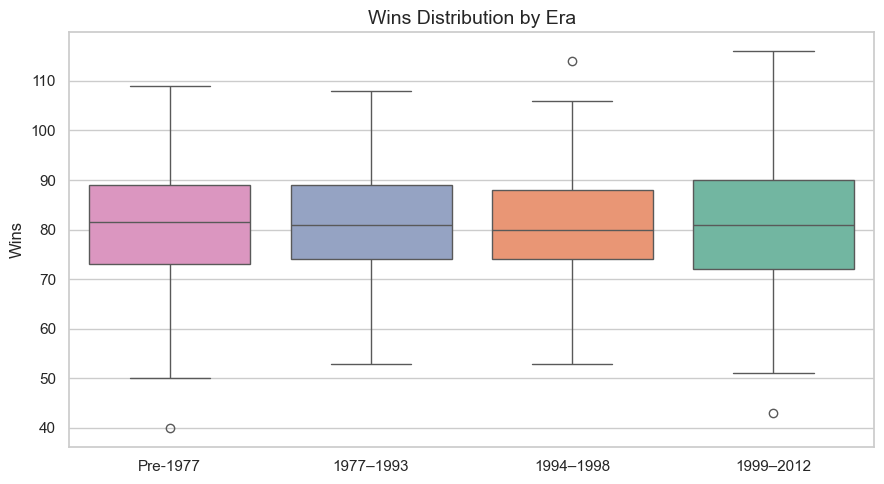

In [12]:
# --- Wins distribution by era ---

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Era', y='W', order=era_order,
            hue='Era', palette='Set2', legend=False, ax=ax)
ax.set_title('Wins Distribution by Era')
ax.set_xlabel(''); ax.set_ylabel('Wins')
plt.tight_layout(); plt.show()

Wins distributions are remarkably consistent across all four eras. Each has a median right around 81 wins and similar IQR spread, confirming that competitive balance in MLB has remained stable regardless of the offensive environment of the era. The outliers in each era represent exceptional teams rather than any structural shift.

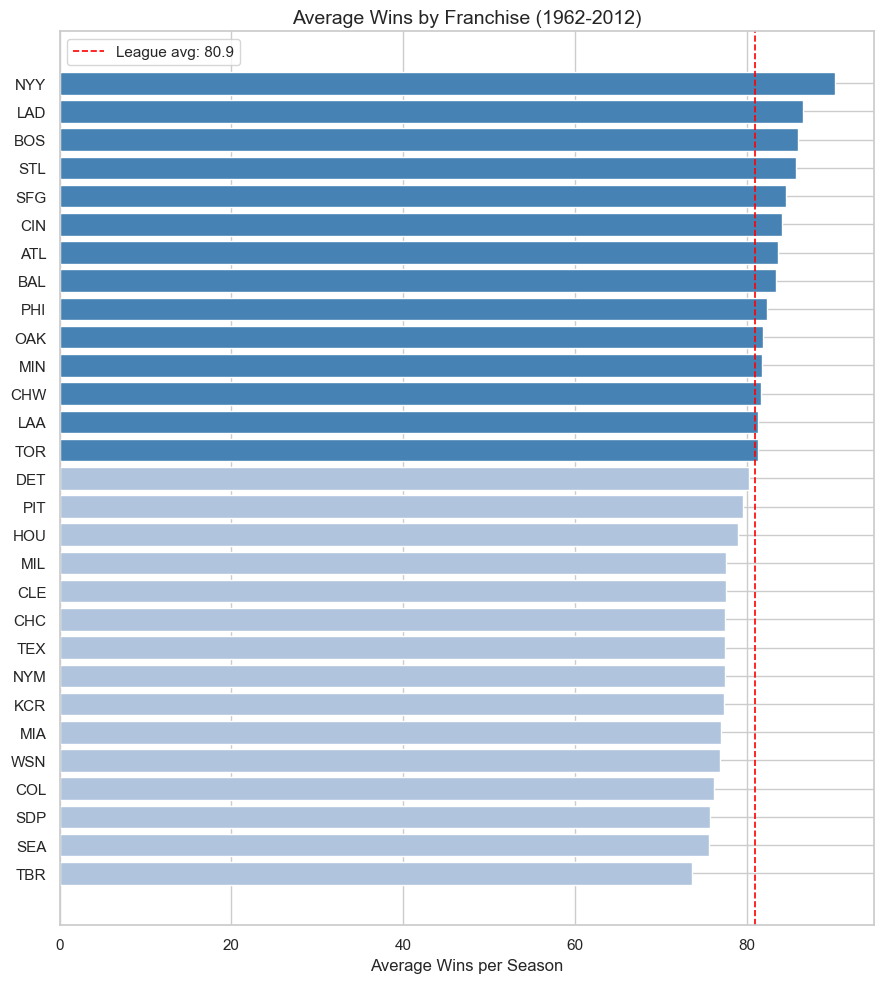

In [13]:
# --- Average wins by franchise ---

franchise_cols = [c for c in df.columns if c.startswith('Franchise_')]
franchise_avgs = {c.replace('Franchise_', ''): df[df[c] == True]['W'].mean()
                  for c in franchise_cols}
franchise_series = pd.Series(franchise_avgs).sort_values()
colors = ['steelblue' if v >= df['W'].mean() else 'lightsteelblue'
          for v in franchise_series]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(franchise_series.index, franchise_series.values, color=colors, edgecolor='white')
ax.axvline(df['W'].mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'League avg: {df["W"].mean():.1f}')
ax.set_xlabel('Average Wins per Season')
ax.set_title('Average Wins by Franchise (1962-2012)')
ax.legend()
plt.tight_layout(); plt.show()

Observations:
- The New York Yankees lead all franchises by a comfortable margin (~90 avg wins), followed by LAD, BOS, and STL; all historic powerhouses with sustained success across the full 50-year span.

- The spread between the best (NYY ~90) and worst (TBR ~73) franchises is only about 17 wins per season, which is surprisingly narrow and reinforces the competitive balance observation from the era box plots.

- Notably, OAK sits just above the league average despite being one of the lowest-payroll teams in baseball — a direct nod to the Moneyball approach of maximizing wins through analytics rather than spending.

- Most expansion franchises (TBR, SEA, COL, MIA) cluster at the bottom, which is expected given they entered the league later and had fewer seasons to accumulate wins in this dataset.

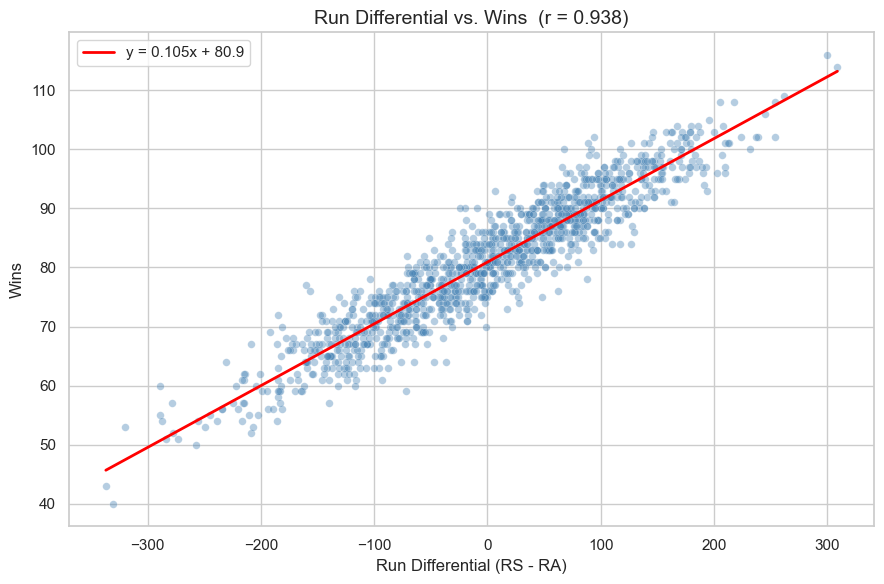

In [14]:
# --- run_diff vs W scatter + regression line ---

# Create a 9x6 inch figure and axes object
fig, ax = plt.subplots(figsize=(9, 6))

# Plot each team-season as a point; alpha=0.4 for transparency to show density
ax.scatter(df['run_diff'], df['W'], alpha=0.4, color='steelblue',
           edgecolors='white', linewidth=0.3, s=30)

# Fit a degree-1 (linear) polynomial to run_diff vs W — returns slope (m) and intercept (b)
m, b = np.polyfit(df['run_diff'], df['W'], 1)

# Generate 200 evenly spaced x values across the range of run_diff for a smooth line
x_line = np.linspace(df['run_diff'].min(), df['run_diff'].max(), 200)

# Plot the regression line using the fitted slope and intercept
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'y = {m:.3f}x + {b:.1f}')

ax.set_xlabel('Run Differential (RS - RA)')
ax.set_ylabel('Wins')

# Compute Pearson r on the fly and embed it in the title
ax.set_title(f'Run Differential vs. Wins  (r = {df["run_diff"].corr(df["W"]):.3f})')

ax.legend()
plt.tight_layout(); plt.show()


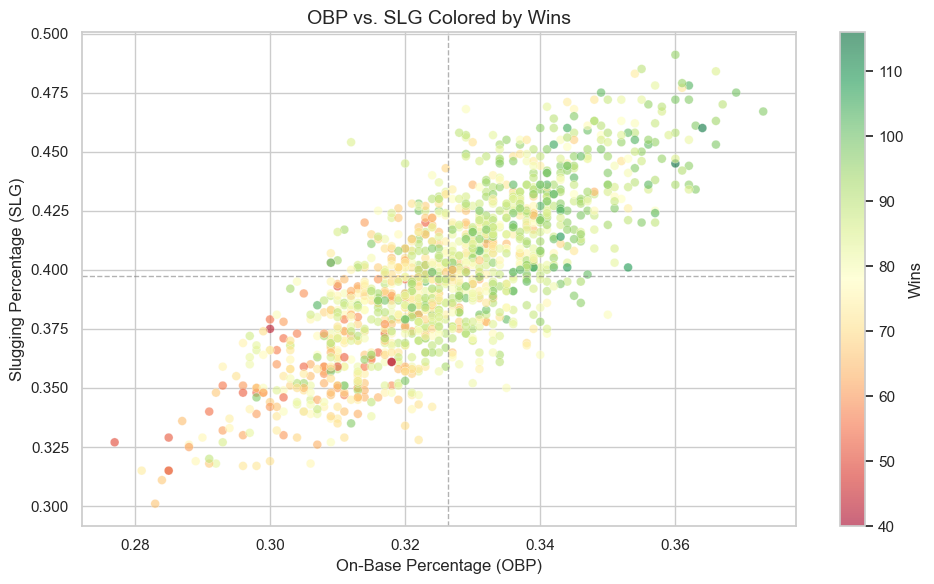

In [15]:
# --- OBP vs SLG colored by W ---

# Create a 10x6 inch figure and axes object
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter each team-season; c=df['W'] maps win totals to color via the colormap
# RdYlGn: red = low wins, yellow = average, green = high wins
sc = ax.scatter(df['OBP'], df['SLG'], c=df['W'], cmap='RdYlGn',
               alpha=0.6, edgecolors='white', linewidth=0.3, s=40)

# Attach a colorbar to the scatter so the win scale is readable
plt.colorbar(sc, ax=ax, label='Wins')

# Vertical line at mean OBP - divides plot into below/above average on-base
ax.axvline(df['OBP'].mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Horizontal line at mean SLG - divides plot into below/above average slugging
# Together the two lines create four quadrants for visual interpretation
ax.axhline(df['SLG'].mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('On-Base Percentage (OBP)')
ax.set_ylabel('Slugging Percentage (SLG)')
ax.set_title('OBP vs. SLG Colored by Wins')
plt.tight_layout(); plt.show()


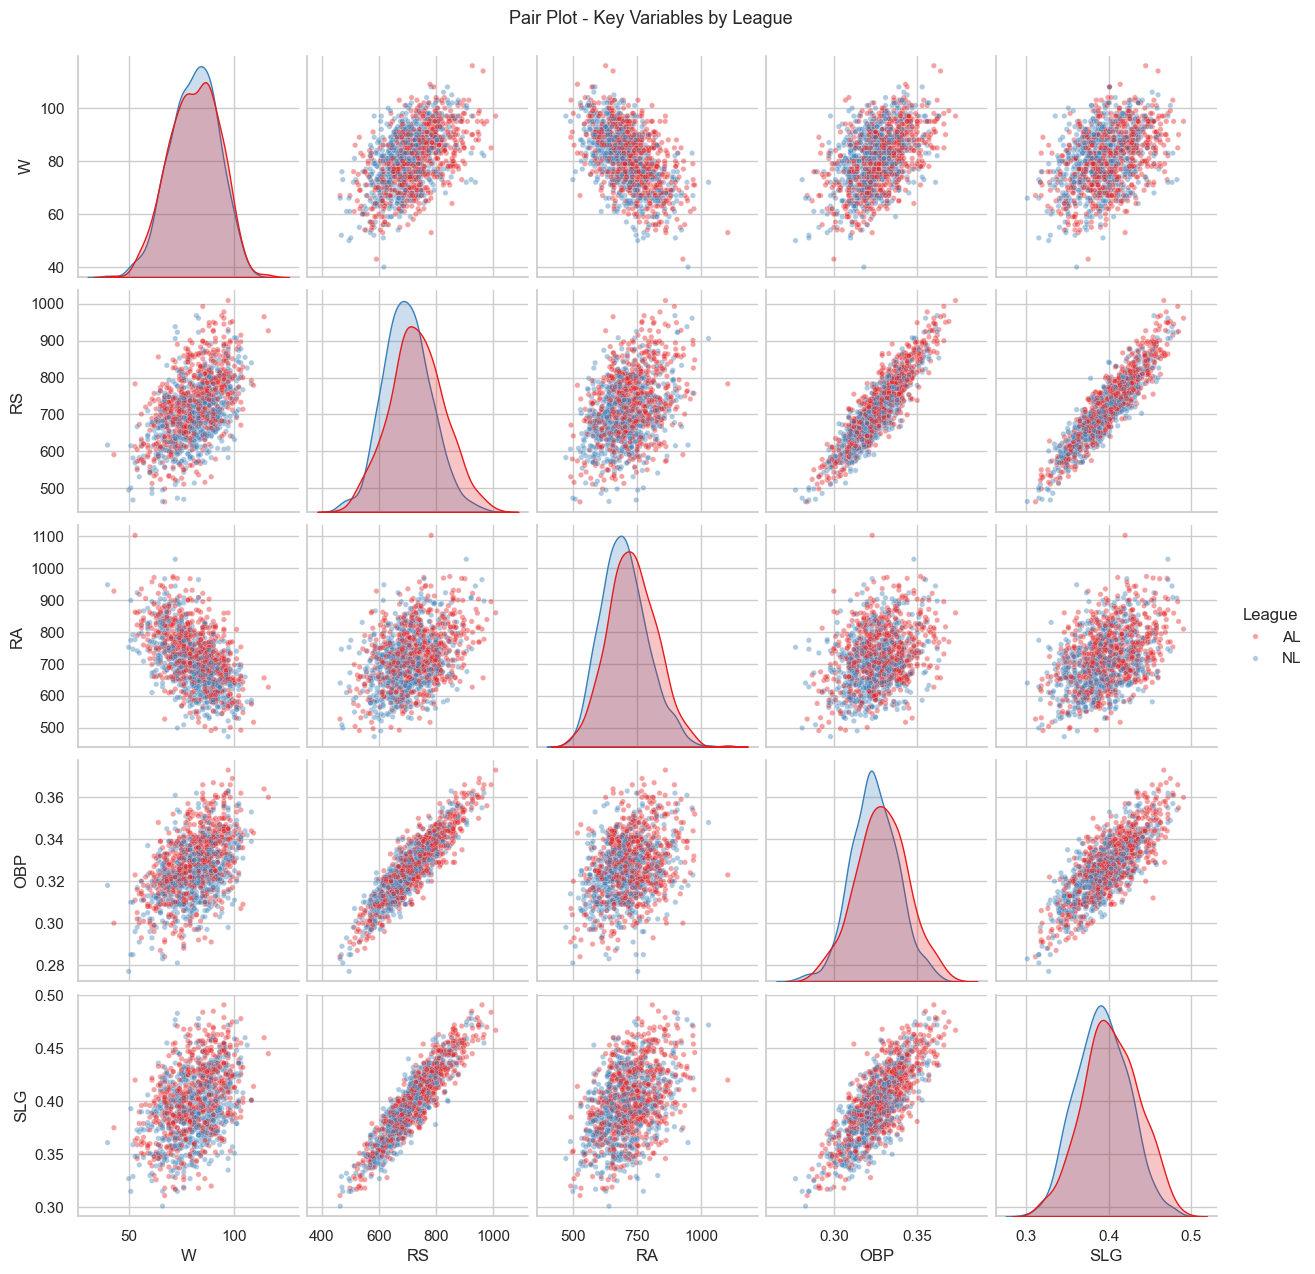

In [16]:
# --- Pair plot ---

# Select the 5 key variables of interest for the pairwise comparison
pair_vars = ['W', 'RS', 'RA', 'OBP', 'SLG']

# Include League as a hue column; .copy() avoids modifying the original df
pair_df = df[pair_vars + ['League']].copy()

# pairplot generates an n×n grid of plots for every variable combination:
#   - off-diagonal: scatter plots colored by League (AL vs NL)
#   - diagonal: KDE curves showing each variable's distribution per league
#   - plot_kws applies scatter styling (alpha for transparency, s for point size)
g = sns.pairplot(pair_df, hue='League', palette='Set1',
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')

# suptitle sits above the grid; y=1.02 prevents overlap with the top row of plots
g.figure.suptitle('Pair Plot - Key Variables by League', y=1.02, fontsize=13)
plt.show()

## Data Analytics <a class="anchor" id="data-analytics"></a>